<a href="https://colab.research.google.com/github/nykollg/TRABAJO-GRADO/blob/main/Calidad_de_vida.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files # Para cargar archivos en google colab
uploaded = files.upload()

Saving DBF_ENCV_591_3.CSV to DBF_ENCV_591_3.CSV


In [ ]:
import pandas as pd
import io
from sklearn.metrics import precision_score
datos_calidad = pd.read_csv(io.BytesIO(uploaded['DBF_ENCV_591_3.CSV']), delimiter=';')
datos_calidad.head(4) # Me muestra las primeras n líneas de la tabla

,DIRECTORIO,SECUENCIA_ENCUESTA,SECUENCIA_P,ORDEN,FEX_C,P1079,P9010,P9025,P9025S1,P9025S2,...,P3525S1,P3525S2,P3525S3,P3525S4,P3525S5,P3525S6,P3525S7,P3525S8,prob_iams,prob_ias
0,7787900,1,1,1,143.618606,1,1,NaN,2,2,...,NaN,1.0,NaN,1.0,NaN,1.0,NaN,NaN,0.7268,0.0001
1,7787901,1,1,1,273.731538,1,1,NaN,2,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.9343,0.0051
2,7787902,1,1,1,367.458347,1,1,NaN,2,2,...,NaN,1.0,NaN,1.0,NaN,NaN,NaN,NaN,0.0000,0.0000
3,7787903,1,1,1,449.276475,1,2,NaN,1,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.1077,0.0000


In [ ]:
datos_calidad.P1077S2.isnull()# da verdadero si la celda es nula

,P1077S2
0,False
1,False
2,False
3,False
4,False
...,...
88323,False
88324,False
88325,False
88326,False


In [ ]:
datos_calidad.loc[datos_calidad.P1077S2.notnull(), "P1077S2"] #selecciona y devuelve todos los valores de la columna que no son nulos

,P1077S2
0,1
1,1
2,1
3,1
4,1
...,...
88323,1
88324,2
88325,1
88326,2


In [ ]:
datos_calidad.loc[datos_calidad.P9090.notnull(), "P9090"]

,P9090
0,1
1,1
2,1
3,1
4,1
...,...
88323,2
88324,1
88325,1
88326,1


In [ ]:
datos_calidad.loc[datos_calidad.P1075.notnull(), "P1075"]

,P1075
0,1
1,1
2,1
3,2
4,2
...,...
88323,1
88324,2
88325,2
88326,2


In [ ]:
datos_calidad.loc[datos_calidad.P3353.notnull(), "P3353"]

,P3353
0,2
1,4
2,3
3,4
4,2
...,...
88323,4
88324,4
88325,4
88326,3


In [ ]:
datos_calidad.loc[datos_calidad.P3516S1.notnull(), "P3516S1"]

,P3516S1
0,1
1,1
2,2
3,2
4,1
...,...
88323,1
88324,1
88325,2
88326,1


In [ ]:
tabla_calidad = datos_calidad[["P9090", "P1077S2", "P1075", "P3353", "P3516S1"]]
tabla_calidad1 = tabla_calidad[tabla_calidad.P1077S2.notnull()]
tabla_calidad1.head(4)

,P9090,P1077S2,P1075,P3353,P3516S1
0,1,1,1,2,1
1,1,1,1,4,1
2,1,1,1,3,2
3,1,1,2,4,2


In [ ]:
dummi_calidad = pd.get_dummies(tabla_calidad1, columns=[ "P1077S2", "P1075", "P3353", "P3516S1"], dtype = float)
dummi_calidad.head(5)

,P9090,P1077S2_1,P1077S2_2,P1075_1,P1075_2,P3353_1,P3353_2,P3353_3,P3353_4,P3353_5,P3516S1_1,P3516S1_2,P3516S1_3
0,1,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,1,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
2,1,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,1,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,1,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


In [ ]:
tabla_calidad1.P9090.value_counts()

,count
P9090,
1,44988
2,39758
3,3582


In [ ]:
dummi_calidad.columns

Index(['P9090', 'P1077S2_1', 'P1077S2_2', 'P1075_1', 'P1075_2', 'P3353_1',
       'P3353_2', 'P3353_3', 'P3353_4', 'P3353_5', 'P3516S1_1', 'P3516S1_2',
       'P3516S1_3'],
      dtype='object')

In [ ]:
dummi_calidad.rename(columns = {'P1077S2_1':'Tiene nev', 'P1077S2_2':'no tiene nev'}, inplace = True)
dummi_calidad.rename(columns = {'P1075_1':"Tiene internet", 'P1075_2':"No tiene internet"}, inplace = True)
dummi_calidad.rename(columns = {'P3353_1':"Mucho mejor", 'P3353_2':"Mejor", 'P3353_3':"Igual", 'P3353_4':"Peor", 'P3353_5':"Mucho peor"}, inplace = True)
dummi_calidad.rename(columns = {'P3516S1_1':"sí se preocupó", 'P3516S1_2':"no se preocupó", 'P3516S1_3':"no sabe/responde"}, inplace = True)
dummi_calidad.head(5)

,P9090,Tiene nev,no tiene nev,Tiene internet,No tiene internet,Mucho mejor,Mejor,Igual,Peor,Mucho peor,sí se preocupó,no se preocupó,no sabe/responde
0,1,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,1,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
2,1,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,1,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,1,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


In [ ]:
x = dummi_calidad.drop(["P9090", 'P9090'], axis = 1)
y = dummi_calidad["P9090"].astype(str)
y.loc[(y == "1")] = "No alcanza"
y.loc[(y == "2")] = "Solo alcanza"
y.loc[(y == "3")] = "Cubre más"
y.value_counts()

,count
P9090,
No alcanza,44988
Solo alcanza,39758
Cubre más,3582


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

Matriz análisis discriminante

Matriz de Confusión:
[[  54   79  613]
 [  44 6790 2189]
 [ 102 2897 4898]]
Exactitud del modelo: 0.66
Precisión para cada clase:
Clase Cubre más: 0.27
Clase No alcanza: 0.70
Clase Solo alcanza: 0.64

Precisión promedio (macro): 0.53


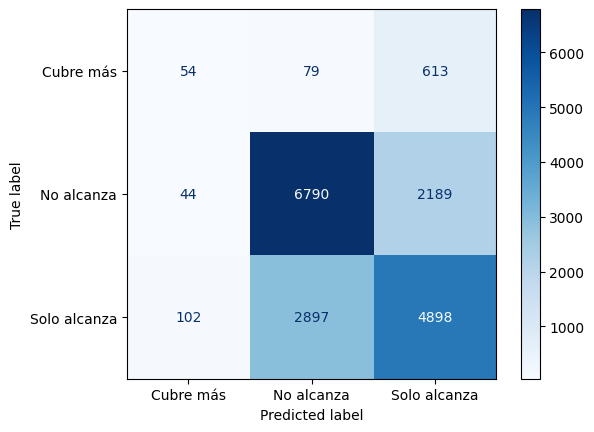

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(x, y_encoded, test_size=0.2, random_state=40)

model = LinearDiscriminantAnalysis()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
print("Matriz de Confusión:")
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap='Blues')

accuracy = accuracy_score(y_test, y_pred)
print(f"Exactitud del modelo: {accuracy:.2f}")
# Calcular la precisión para cada clase
precision = precision_score(y_test, y_pred, average=None)  # average=None devuelve la precisión para cada clase

# Calcular la precisión promedio (macro)
precision_macro = precision_score(y_test, y_pred, average='macro')

# Imprimir la precisión
print("Precisión para cada clase:")
for i, prec in enumerate(precision):
    print(f"Clase {label_encoder.classes_[i]}: {prec:.2f}")

print(f"\nPrecisión promedio (macro): {precision_macro:.2f}")


Matriz Ridge de clasificación

Matriz de Confusión:
[[   0   79  669]
 [   0 6747 2177]
 [   0 2919 5075]]
Exactitud del modelo: 0.67
Precisión para cada clase:
Clase Cubre más: 0.00
Clase No alcanza: 0.69
Clase Solo alcanza: 0.64

Precisión promedio (macro): 0.44


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


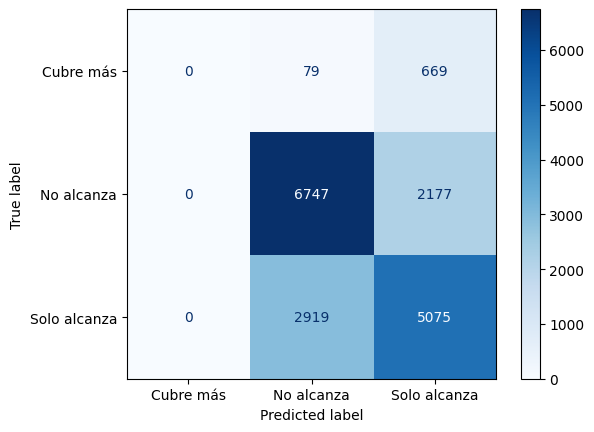

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import RidgeClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(x, y_encoded, test_size=0.2, random_state=42)

model = RidgeClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
print("Matriz de Confusión:")
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap='Blues')

accuracy = accuracy_score(y_test, y_pred)
print(f"Exactitud del modelo: {accuracy:.2f}")
# Calcular la precisión para cada clase
precision = precision_score(y_test, y_pred, average=None)  # average=None devuelve la precisión para cada clase

# Calcular la precisión promedio (macro)
precision_macro = precision_score(y_test, y_pred, average='macro')

# Imprimir la precisión
print("Precisión para cada clase:")
for i, prec in enumerate(precision):
    print(f"Clase {label_encoder.classes_[i]}: {prec:.2f}")

print(f"\nPrecisión promedio (macro): {precision_macro:.2f}")

Matriz Vecinos más cercanos

Matriz de Confusión:
[[ 198  115  435]
 [ 128 5458 3338]
 [ 612 2925 4457]]
Exactitud del modelo: 0.57
Precisión para cada clase:
Clase Cubre más: 0.21
Clase No alcanza: 0.64
Clase Solo alcanza: 0.54

Precisión promedio (macro): 0.46


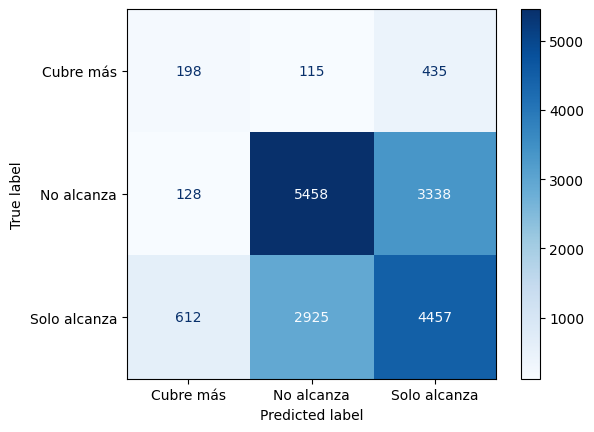

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(x, y_encoded, test_size=0.2, random_state=42)

model = KNeighborsClassifier(n_neighbors=5)  # Es posible cambiar la cantidad de vecinos
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
print("Matriz de Confusión:")
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap='Blues')

accuracy = accuracy_score(y_test, y_pred)
print(f"Exactitud del modelo: {accuracy:.2f}")
# Calcular la precisión para cada clase
precision = precision_score(y_test, y_pred, average=None)  # average=None devuelve la precisión para cada clase

# Calcular la precisión promedio (macro)
precision_macro = precision_score(y_test, y_pred, average='macro')

# Imprimir la precisión
print("Precisión para cada clase:")
for i, prec in enumerate(precision):
    print(f"Clase {label_encoder.classes_[i]}: {prec:.2f}")

print(f"\nPrecisión promedio (macro): {precision_macro:.2f}")

Matriz "Claisificación Bayes Naive"

Matriz de Confusión:
[[ 504   62  182]
 [ 678 6051 2195]
 [2557 2421 3016]]
Exactitud del modelo: 0.54
Precisión para cada clase:
Clase Cubre más: 0.13
Clase No alcanza: 0.71
Clase Solo alcanza: 0.56

Precisión promedio (macro): 0.47


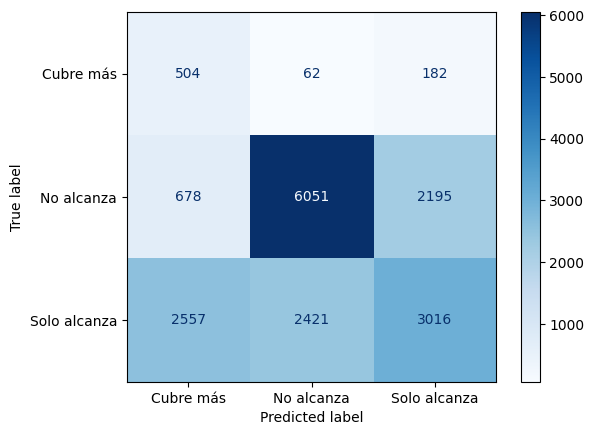

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(x, y_encoded, test_size=0.2, random_state=42)

model = GaussianNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
print("Matriz de Confusión:")
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap='Blues')

accuracy = accuracy_score(y_test, y_pred)
print(f"Exactitud del modelo: {accuracy:.2f}")
# Calcular la precisión para cada clase
precision = precision_score(y_test, y_pred, average=None)  # average=None devuelve la precisión para cada clase

# Calcular la precisión promedio (macro)
precision_macro = precision_score(y_test, y_pred, average='macro')

# Imprimir la precisión
print("Precisión para cada clase:")
for i, prec in enumerate(precision):
    print(f"Clase {label_encoder.classes_[i]}: {prec:.2f}")

print(f"\nPrecisión promedio (macro): {precision_macro:.2f}")

Matriz gradiente boosted arboles

Matriz de Confusión:
[[   0   72  676]
 [   0 6713 2211]
 [   0 2876 5118]]
Exactitud del modelo: 0.67
Precisión para cada clase:
Clase Cubre más: 0.00
Clase No alcanza: 0.69
Clase Solo alcanza: 0.64

Precisión promedio (macro): 0.44


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


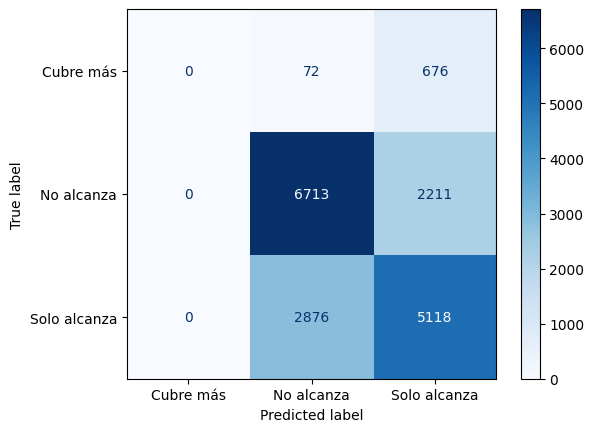

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(x, y_encoded, test_size=0.2, random_state=42)

model = GradientBoostingClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
print("Matriz de Confusión:")
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap='Blues')

accuracy = accuracy_score(y_test, y_pred)
print(f"Exactitud del modelo: {accuracy:.2f}")
# Calcular la precisión para cada clase
precision = precision_score(y_test, y_pred, average=None)  # average=None devuelve la precisión para cada clase

# Calcular la precisión promedio (macro)
precision_macro = precision_score(y_test, y_pred, average='macro')

# Imprimir la precisión
print("Precisión para cada clase:")
for i, prec in enumerate(precision):
    print(f"Clase {label_encoder.classes_[i]}: {prec:.2f}")

print(f"\nPrecisión promedio (macro): {precision_macro:.2f}")

Matriz "Redes para clasificación"

Matriz de Confusión:
[[   0   63  670]
 [   0 6788 2182]
 [   0 2899 5064]]
Exactitud del modelo: 0.67
Precisión para cada clase:
Clase Cubre más: 0.00
Clase No alcanza: 0.70
Clase Solo alcanza: 0.64

Precisión promedio (macro): 0.45


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


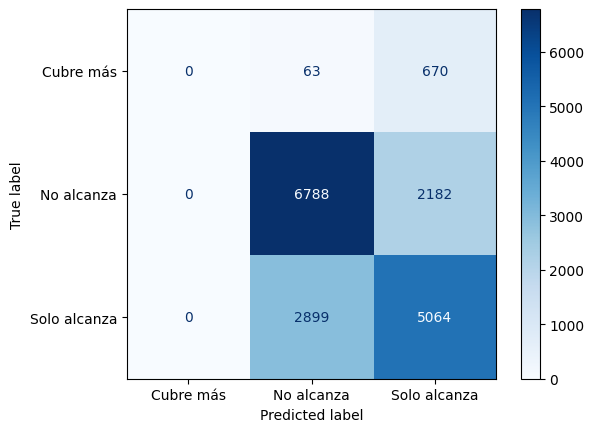

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(x, y_encoded, test_size=0.2, random_state=50)

model = MLPClassifier(random_state=50, max_iter=700)  # Es posible un cambio de parametros
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
print("Matriz de Confusión:")
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap='Blues')

accuracy = accuracy_score(y_test, y_pred)
print(f"Exactitud del modelo: {accuracy:.2f}")
# Calcular la precisión para cada clase
precision = precision_score(y_test, y_pred, average=None)  # average=None devuelve la precisión para cada clase

# Calcular la precisión promedio (macro)
precision_macro = precision_score(y_test, y_pred, average='macro')

# Imprimir la precisión
print("Precisión para cada clase:")
for i, prec in enumerate(precision):
    print(f"Clase {label_encoder.classes_[i]}: {prec:.2f}")

print(f"\nPrecisión promedio (macro): {precision_macro:.2f}")


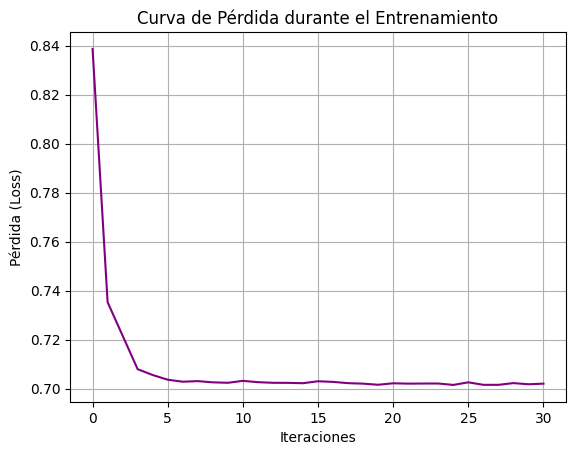

In [ ]:
mlp_clf = MLPClassifier(hidden_layer_sizes=(50, 50, 50, 50, 50, 50, 50),
                        max_iter=300, activation='logistic',
                        solver='adam', random_state=42)

# Entrenamiento del modelo con los datos de entrenamiento
mlp_clf.fit(X_train, y_train)

# Predicciones en el conjunto de prueba
y_pred = mlp_clf.predict(X_test)

# Graficar la curva de pérdida
plt.plot(mlp_clf.loss_curve_, color='purple')  # Cambia el color según prefieras
plt.title("Curva de Pérdida durante el Entrenamiento")
plt.xlabel('Iteraciones')
plt.ylabel('Pérdida (Loss)')
plt.grid(True)
plt.show()

Matriz maquina de soporte vectorial

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [ ]:
from sklearn.svm import SVC
soporte_vect = SVC(decision_function_shape='ovr', kernel = "rbf", degree = 3)
soporte_vect.fit(X_train, y_train)
y_pred_sopor = soporte_vect.predict(X_test)
print('Accuracy: {:.2f}'.format(accuracy_score(y_pred_sopor, y_test)))

Accuracy: 0.67


Exactitud del modelo: 0.67
Precisión para cada clase:
Clase Cubre más: 0.00
Clase No alcanza: 0.70
Clase Solo alcanza: 0.64

Precisión promedio (macro): 0.45


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


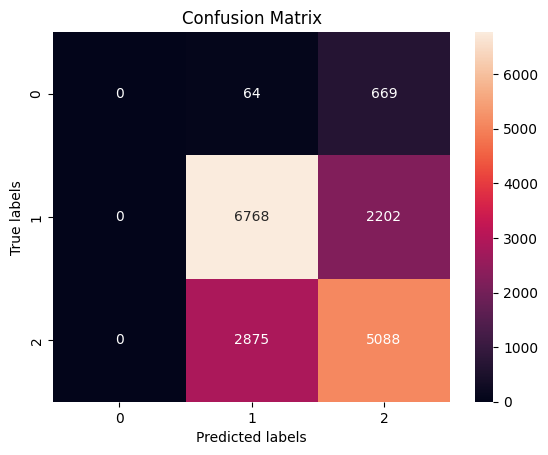

In [ ]:
from sklearn.metrics import confusion_matrix
import pylab as pl
cm2 = confusion_matrix(y_test, y_pred_sopor)
cm2
import seaborn as sns
import matplotlib.pyplot as plt
ax= plt.subplot()
sns.heatmap(cm2, annot=True, fmt='g', ax=ax);
ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels');
ax.set_title('Confusion Matrix')

accuracy = accuracy_score(y_test, y_pred)
print(f"Exactitud del modelo: {accuracy:.2f}")
# Calcular la precisión para cada clase
precision = precision_score(y_test, y_pred, average=None)  # average=None devuelve la precisión para cada clase

# Calcular la precisión promedio (macro)
precision_macro = precision_score(y_test, y_pred, average='macro')

# Imprimir la precisión
print("Precisión para cada clase:")
for i, prec in enumerate(precision):
    print(f"Clase {label_encoder.classes_[i]}: {prec:.2f}")

print(f"\nPrecisión promedio (macro): {precision_macro:.2f}")

Analisis discriminante felxible

In [ ]:
pip install pygam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 522.0/522.0 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 18.7 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.13.1
    Uninstalling scipy-1.13.1:
      Successfully uninstalled scipy-1.13.1


Matriz de Confusión:
[[144   7]
 [  7 142]]

Exactitud del modelo: 0.95
Precisión para cada clase:
Clase 0: 0.95
Clase 1: 0.95

Precisión promedio (macro): 0.95


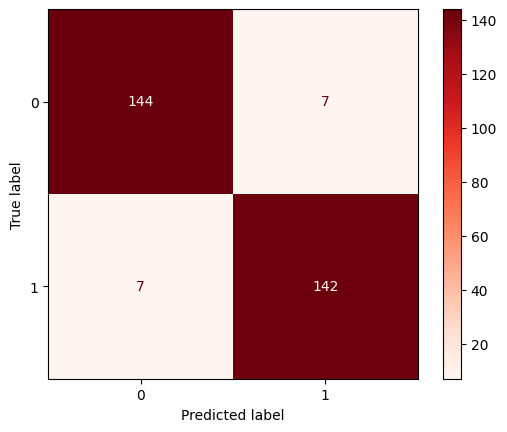

In [ ]:
import numpy as np
from pygam import LogisticGAM, s
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score
from sklearn.model_selection import train_test_split

# Simulamos algunos datos (usa tus datos reales aquí)
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=1000, n_features=5, n_informative=3, n_redundant=2, random_state=42)

# Dividimos los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Codificar las etiquetas si es necesario

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Configurar y entrenar el modelo de FDA
fda = LogisticGAM(s(0) + s(1) + s(2) + s(3) + s(4))  # Ajustamos un spline por cada variable
fda.fit(X_train, y_train_encoded)

# Realizar predicciones
y_pred = fda.predict(X_test)

# Calcular y mostrar la matriz de confusión
cm = confusion_matrix(y_test_encoded, y_pred)
print("Matriz de Confusión:")
print(cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap='Reds')

# Calcular métricas de desempeño
accuracy = accuracy_score(y_test_encoded, y_pred)
print(f"\nExactitud del modelo: {accuracy:.2f}")

# Calcular la precisión para cada clase
precision = precision_score(y_test_encoded, y_pred, average=None)
precision_macro = precision_score(y_test_encoded, y_pred, average='macro')

# Imprimir la precisión
print("Precisión para cada clase:")
for i, prec in enumerate(precision):
    print(f"Clase {label_encoder.classes_[i]}: {prec:.2f}")

print(f"\nPrecisión promedio (macro): {precision_macro:.2f}")

In [ ]:
from sklearn.linear_model import LogisticRegression
models = {
    #'Random Forest': RandomForestClassifier(random_state=42),
    'Gaussian Naive Bayes': GaussianNB(),
    #'QuadraticDiscriminantAnalysis': QuadraticDiscriminantAnalysis(),
    #'SVC': SVC(),
    'LinearDiscriminantAnalysis': LinearDiscriminantAnalysis(),
    'RidgeClassifier': RidgeClassifier(),
    'KNeighborsClassifier': KNeighborsClassifier(n_neighbors=5),
    'GradientBoostingClassifier': GradientBoostingClassifier(),
    'MLPClassifier': MLPClassifier(random_state=42, max_iter=500),
    'LogisticRegression': LogisticRegression(random_state=42),
}


    # Puedes agregar más modelos aquí

# Inicializar un diccionario para almacenar las métricas
model_metrics = {}

# Entrenar y evaluar cada modelo
for model_name, model in models.items():
    # Entrenar el modelo
    model.fit(X_train, y_train)

    # Realizar predicciones
    y_pred = model.predict(X_test)

    # Calcular exactitud y precisión
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro', zero_division=0)  # Evitar advertencia

    # Almacenar métricas en el diccionario
    model_metrics[model_name] = {'exactitud': accuracy, 'precisión': precision}

# Convertir a DataFrame para facilitar la comparación
metrics_df = pd.DataFrame(model_metrics).T  # Transponer para tener modelos como filas
metrics_df['promedio'] = metrics_df[['exactitud', 'precisión']].mean(axis=1)

# Encontrar el mejor modelo basado en la exactitud y precisión
mejor_modelo_exactitud = metrics_df.loc[metrics_df['exactitud'].idxmax()]

# Encontrar el mejor modelo basado en la precisión
mejor_modelo_precision = metrics_df.loc[metrics_df['precisión'].idxmax()]

# Imprimir resultados
print("Métricas de los modelos:")
print(metrics_df)

print("\nMejor modelo por exactitud:")
print(mejor_modelo_exactitud)

print("\nMejor modelo por precisión:")
print(mejor_modelo_precision)

Métricas de los modelos:
                            exactitud  precisión  promedio
Gaussian Naive Bayes         0.545907   0.471661  0.508784
LinearDiscriminantAnalysis   0.668120   0.531517  0.599818
RidgeClassifier              0.671006   0.445365  0.558186
KNeighborsClassifier         0.644062   0.549723  0.596893
GradientBoostingClassifier   0.671063   0.445463  0.558263
MLPClassifier                0.671289   0.445623  0.558456
LogisticRegression           0.671233   0.445527  0.558380

Mejor modelo por exactitud:
exactitud    0.671289
precisión    0.445623
promedio     0.558456
Name: MLPClassifier, dtype: float64

Mejor modelo por precisión:
exactitud    0.644062
precisión    0.549723
promedio     0.596893
Name: KNeighborsClassifier, dtype: float64
